In [118]:
#load libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split,KFold, cross_validate,GridSearchCV
from sklearn.pipeline import Pipeline #both preprocessing and model together
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

from sklearn.metrics import  accuracy_score,  mean_absolute_error, root_mean_squared_error, r2_score  


In [119]:
#configuration
pd.set_option('display.max_columns', None)
sns.set_theme(style ='darkgrid')
PALETTE = {}
RANDOM_STATE = 42
CSV_PATH = r"C:\Users\PC\Desktop\customer_churn_downloaded.csv"
TARGET_COL = "Price"  #target column name

In [120]:
#load data
df = pd.read_csv(CSV_PATH)

In [121]:
df.shape

(2000, 10)

In [122]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [123]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='str')

In [124]:
df.dtypes

Id           int64
Area         int64
Bedrooms     int64
Bathrooms    int64
Floors       int64
YearBuilt    int64
Location       str
Condition      str
Garage         str
Price        int64
dtype: object

In [125]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 156.4 KB


In [126]:
num_cols = df.select_dtypes(include = [np.number]).columns.tolist()
cat_cols = df.select_dtypes(include = ["object"]).columns.tolist()

print("TARGET_COLUMN: ",TARGET_COL)
print("NUMERICAL COLUMNS: ", num_cols)
print("CATEGORICAL COLUMNS: ", cat_cols)

TARGET_COLUMN:  Price
NUMERICAL COLUMNS:  ['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price']
CATEGORICAL COLUMNS:  ['Location', 'Condition', 'Garage']


C:\Users\PC\AppData\Local\Temp\ipykernel_10140\122865677.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include = ["object"]).columns.tolist()


In [127]:
#missing value analysis
df.isna().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [128]:
for col in df.columns:
    print(df[col].value_counts().head(20))

Id
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    1
18    1
19    1
20    1
Name: count, dtype: int64
Area
4219    5
1516    4
3691    4
1743    4
4646    4
1752    4
3419    3
741     3
1275    3
3652    3
2000    3
3604    3
1304    3
988     3
3670    3
2182    3
1456    3
1454    3
3274    3
1074    3
Name: count, dtype: int64
Bedrooms
1    418
3    406
4    405
5    403
2    368
Name: count, dtype: int64
Bathrooms
3    524
4    521
2    494
1    461
Name: count, dtype: int64
Floors
2    691
1    661
3    648
Name: count, dtype: int64
YearBuilt
2005    27
2002    26
1901    25
1981    24
1938    23
2000    23
1957    23
1932    22
1930    22
1924    22
1970    21
1925    21
2013    21
2014    21
1911    21
2017    21
1976    20
1928    20
1910    20
2003    20
Name: count, dtype: int64
Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64
Condition
Fai

In [129]:
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("total duplicates are: ", num_duplicates)

#optional drop duplicate if present
# df = df.drop_duplicates()
#print("shape after dropping duplicates:", df.shapes)

total duplicates are:  0


In [130]:
df[num_cols].describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [131]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Id,2000.0,1000.5000,577.494589,1.0,500.75,1000.5,1500.25,2000.0
Area,2000.0,2786.2095,1295.146799,501.0,1653.00,2833.0,3887.50,4999.0
Bedrooms,2000.0,3.0035,1.424606,1.0,2.00,3.0,4.00,5.0
Bathrooms,2000.0,2.5525,1.108990,1.0,2.00,3.0,4.00,4.0
Floors,2000.0,1.9935,0.809188,1.0,1.00,2.0,3.00,3.0
YearBuilt,2000.0,1961.4460,35.926695,1900.0,1930.00,1961.0,1993.00,2023.0
Price,2000.0,537676.8550,276428.845719,50005.0,300098.00,539254.0,780086.00,999656.0


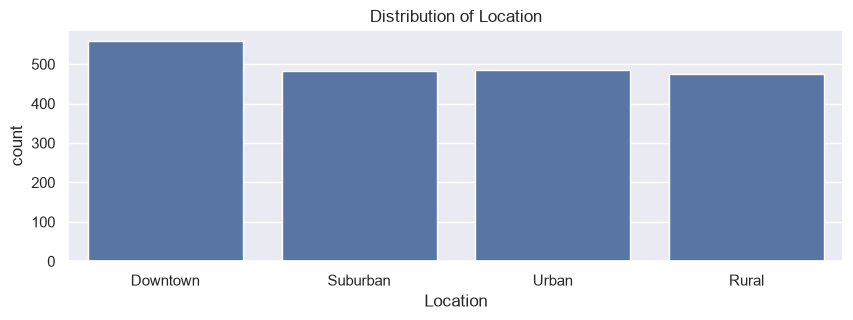

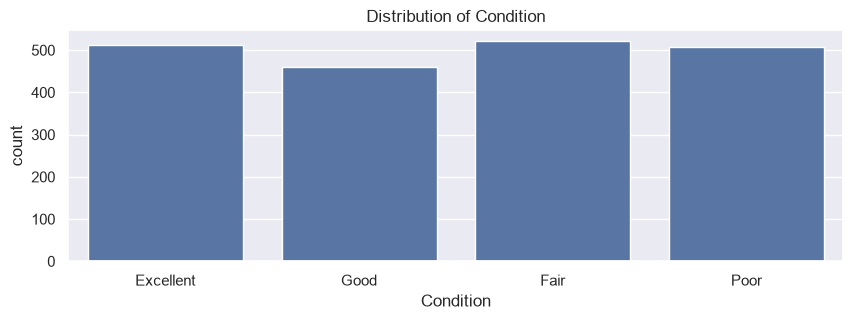

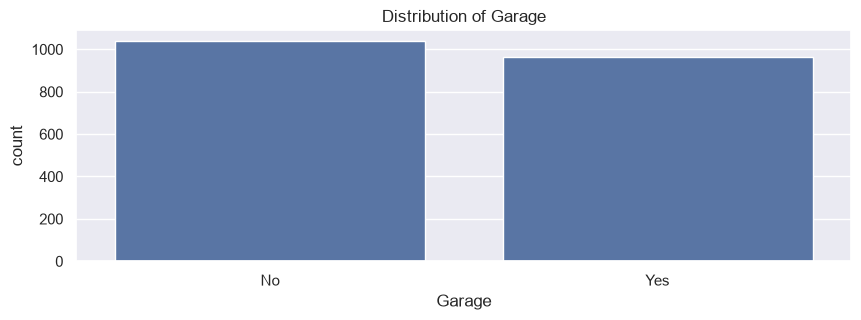

In [132]:
#countplot for categorical columns
for col in cat_cols:
    plt.figure(figsize = (10,3))
    sns.countplot(x = col, data = df)
    plt.title(f"Distribution of {col}")
    plt.show()

In [133]:
for col in cat_cols:
    print(df[col].value_counts())

Location
Downtown    558
Urban       485
Suburban    483
Rural       474
Name: count, dtype: int64
Condition
Fair         521
Excellent    511
Poor         507
Good         461
Name: count, dtype: int64
Garage
No     1038
Yes     962
Name: count, dtype: int64


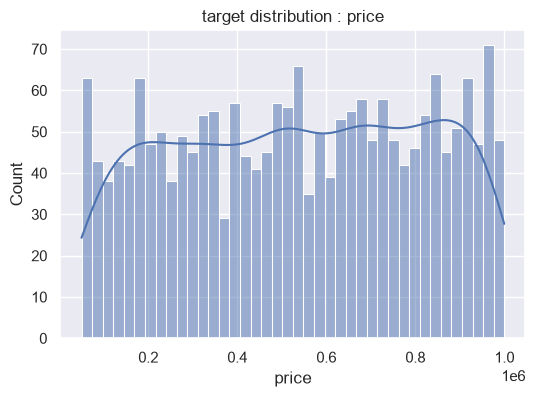

In [134]:
#target columns distribution
plt.figure(figsize = (6,4) )
sns.histplot(df[TARGET_COL], bins = 40 , kde = True)
plt.title("target distribution : price")
plt.xlabel("price")
plt.show()

In [135]:
df[TARGET_COL].value_counts()

Price
959222    2
149919    1
424998    1
266746    1
244020    1
         ..
295620    1
580929    1
476925    1
161119    1
482525    1
Name: count, Length: 1999, dtype: int64

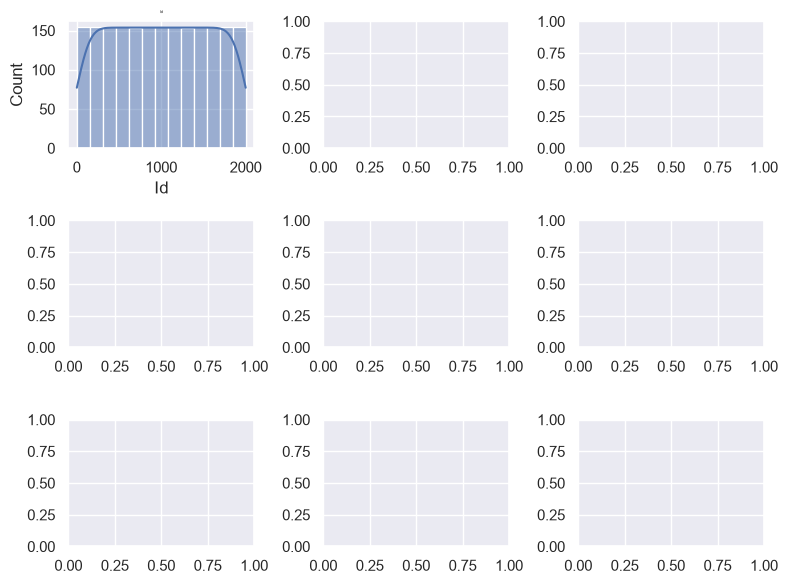

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [136]:
#histogram plot distribution
fig, axes = plt.subplots(3,3, figsize = (8,6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde = True , ax = axes[i])
    axes[i].set_title(col, fontsize = 3)

    plt.tight_layout()
    plt.show()

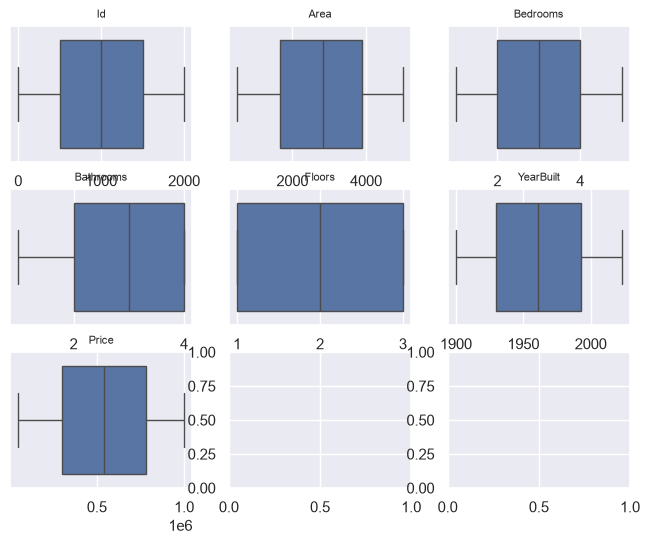

In [137]:
#outliners analysis -boxplot
fig, axes = plt.subplots(3,3, figsize = (8,6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot( x = df[col], ax = axes[i])
    axes[i].set_title(col, fontsize = 8)
    axes[i].set_xlabel("")
    

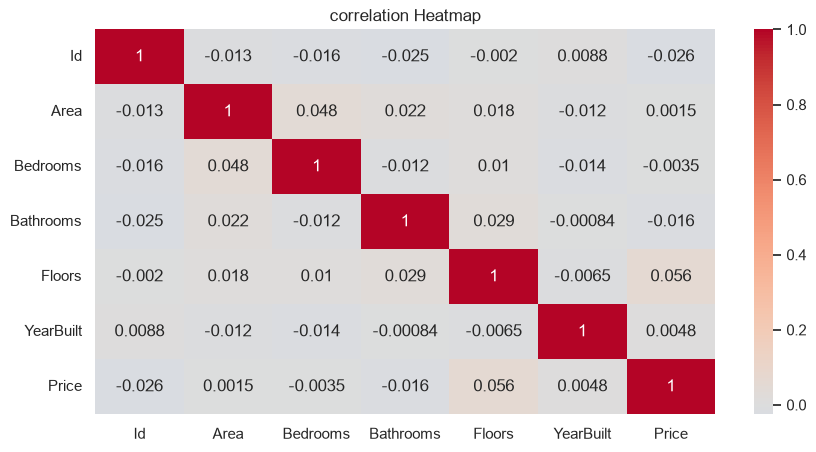

In [138]:
#identify the presence of highly correlated columns and feature relationships
plt.figure(figsize = (10,5))
sns.heatmap(
    df[num_cols].corr(),
    annot =True,
    cmap = "coolwarm",
    center = 0
)
plt.title("correlation Heatmap")
plt.show()

In [139]:
corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending = False)
print("correlation with target:")
print(corr_with_target)

correlation with target:
Price        1.000000
Floors       0.055890
YearBuilt    0.004845
Area         0.001542
Bedrooms    -0.003471
Bathrooms   -0.015737
Id          -0.025643
Name: Price, dtype: float64


In [140]:
#separate features and target
x = df.drop(columns = [TARGET_COL])
y = df[TARGET_COL]

In [141]:
x.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage
0,1,1360,5,4,3,1970,Downtown,Excellent,No
1,2,4272,5,4,3,1958,Downtown,Excellent,No
2,3,3592,2,2,3,1938,Downtown,Good,No
3,4,966,4,2,2,1902,Suburban,Fair,Yes
4,5,4926,1,4,2,1975,Downtown,Fair,Yes


In [142]:
y.head()

0    149919
1    424998
2    266746
3    244020
4    636056
Name: Price, dtype: int64

In [143]:
#train test split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = RANDOM_STATE
    
)

In [144]:
#preprocessing pipeline
numerical_features = x_train.select_dtypes(include = [np.number]).columns.tolist()
categorical_features = x_train.select_dtypes(exclude =[np.number]).columns.tolist()
print("numerical_features: " , numerical_features)
print("categorical_features: ", categorical_features)

#numerical features - preprocessing steps
numerical_transformer =Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy = "median")),
        ("scaler", StandardScaler())
    ]
)
#categorical features - preprocessing steps
categorical_transformer = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy = "most_frequent")),
        ("onehot",OneHotEncoder(handle_unknown = "ignore"))
    ]
)


#preprocessing Pipeline
preprocess = ColumnTransformer(
    transformers = [
        ["num", numerical_transformer, numerical_features],
       ["cat",categorical_transformer, categorical_features]
    ]
)


numerical_features:  ['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
categorical_features:  ['Location', 'Condition', 'Garage']


In [145]:
baseline_pipe = Pipeline(
    steps = [
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
)

In [146]:
baseline_pipe.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Id','Area','Bedrooms',...,'Location','Condition','Garage']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[['num', Pipeline(step...ardScaler())]), ...], ['cat', Pipeline(step...n='ignore'))]), ...]]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be aut

In [147]:
#Evaluation of baseline model
train_baseline_pred = baseline_pipe.predict(x_train)
test_baseline_pred = baseline_pipe.predict(x_test)

In [148]:
#print first 5 prediction
train_baseline_pred[:5]

array([523593.72106321, 500483.32076083, 475823.8729011 , 515946.55019386,
       505734.00069984])

In [149]:
y_train[:5]

968    434325
240    614772
819    922811
692    794314
420    796988
Name: Price, dtype: int64

In [150]:
train_baseline_rmse = root_mean_squared_error(y_train,train_baseline_pred)
train_baseline_mae = mean_absolute_error(y_train,train_baseline_pred)
train_baseline_r2 = r2_score(y_train,train_baseline_pred)


print(" rmse , MAE AND R2 RESPECTIVELY are ",train_baseline_rmse,train_baseline_mae,train_baseline_r2)

 rmse , MAE AND R2 RESPECTIVELY are  274246.37041659927 236994.78129303365 0.010478555046869564


In [151]:
test_baseline_rmse = root_mean_squared_error(y_test,test_baseline_pred)
test_baseline_mae = mean_absolute_error(y_test,test_baseline_pred)
test_baseline_r2 = r2_score(y_test,test_baseline_pred)


print(" rmse , MAE AND R2 RESPECTIVELY ARE ",test_baseline_rmse,test_baseline_mae,test_baseline_r2)

 rmse , MAE AND R2 RESPECTIVELY ARE  279785.21069002635 242867.44926338628 -0.006181784611834162


In [152]:

# Give sample prediction
def predict_house_price(
    model,
    Id: int,
    Area: int,
    Bedrooms: int,
    Bathrooms: int,
    Floors: int,
    YearBuilt: int,
    Location: str,
    Condition: str,
    Garage: str
):
    # Create a DataFrame with one row
    new_row = pd.DataFrame([{
        "Id": Id,
        "Area": Area,
        "Bedrooms": Bedrooms,
        "Bathrooms": Bathrooms,
        "Floors": Floors,
        "YearBuilt": YearBuilt,
        "Location": Location,
        "Condition": Condition,
        "Garage": Garage
    }])

    # Predict price
    return float(model.predict(new_row)[0])

In [153]:
example_pred = predict_house_price(
    model=baseline_pipe,
    Id=52,
    Area=34,
    Bedrooms=5,
    Bathrooms=2,
    Floors=1,
    YearBuilt=2008,
    Location="Suburban",
    Condition="Poor",
    Garage="Yes"
)

print("Predicted House Price:", round( example_pred,2 ))

Predicted House Price: 548396.9


In [154]:
import pickle

with open("house_price_model.pkl","wb") as f:
    pickle.dump(baseline_pipe, f)

In [155]:
print(type(baseline_pipe))
print(hasattr(baseline_pipe, "predict"))

<class 'sklearn.pipeline.Pipeline'>
True


In [156]:
'c:/Users/PC/AppData/Local/Programs/Python/Python313/python.exe -m pip install ipykernel -U --user --force-reinstall'

'c:/Users/PC/AppData/Local/Programs/Python/Python313/python.exe -m pip install ipykernel -U --user --force-reinstall'